In [1]:
#%pip install plotly
#%pip install squarify
#%pip install -U scikit-learn

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, OneHotEncoder,StringIndexer, Bucketizer
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType, Row
from pyspark.ml.fpm import FPGrowth
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score
from IPython.display import display, HTML
from datetime import datetime
from pyspark.sql.functions import concat_ws
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
import plotly.express as px
import seaborn as sns
import pandas as pd

In [3]:
#creating the session and the Sparkcontext for RDD manipulation
spark = SparkSession.builder.appName("CRM Analysis").getOrCreate()
sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [4]:
# Recuperation des donnees 
salesData = sc.textFile("./Data/input/International_sale_Report.csv")

In [5]:
# Lire la premiere ligne qui represente l'entete
salesHeader = salesData.first()
salesHeader = salesHeader.split(',')
salesHeader

['index',
 'DATE',
 'Months',
 'CUSTOMER',
 'Style',
 'SKU',
 'Size',
 'PCS',
 'RATE',
 'GROSS AMT']

In [6]:
#remove header from the rdd
salesData = sc.parallelize(salesData.collect()[1:])
nbLines = salesData.count()
'number of lines :', nbLines

('number of lines :', 37432)

In [7]:
# Il faut que les donnees soit de type tuple et non pas list, car on aura besoin de les hasher apres
salesData = salesData.map(lambda str: tuple(str.split(',')))

# Probleme 1 :

- Il y a un swap entre les donnees au niveau des colonnes DATE,Size,PCS,RATE et GROSS AMT. Donc on split les lignes la ou le probleme commence on aurait donc deux rdd, clean et unclean data.


In [8]:
#regex pour detecter les dates, format : jj-MM-yy
dateRe = re.compile("^[0-9]{1,2}\\-[0-9]{1,2}\\-[0-9]{2}$")
cleanData = salesData.filter(lambda l: dateRe.match(l[1])) 
uncleanData = salesData.filter(lambda l: not(dateRe.match(l[1])))

# Probleme 2:

- Dans les donnees non propres, il y a des intrus qui sont les Stock Keeping Unit (SKU). Dans la gestion des stocks, une unité de gestion des stocks est l'unité de mesure dans laquelle les stocks d'un article sont gérés.


In [9]:
skuData = uncleanData.filter(lambda elt: elt[2]=='' and elt[1]!='')
#.map(lambda elt: [elt[0],elt[1]])
skuData.take(2)
#save this to a file

[('18635', 'SKU', '', '', '', '', '', '', '', ''),
 ('18636', 'JNE3826', '', '', '', '', '', '', '', '')]

# Probleme 3:

- Il existe des donnees sur les articles sans aucune info relier a une vent


In [10]:
StyleAndStock= uncleanData.filter(lambda elt: elt[2]!='' and elt[3] =='' )
#.map(lambda elt: [elt[0],elt[1],elt[2]])
StyleAndStock.take(2)

[('18660', 'Style', 'Stock', '', '', '', '', '', '', ''),
 ('18661', 'MEN5004', '43.00', '', '', '', '', '', '', '')]

# Resolution du 1er probleme:

- On retire l'ensemble des donnees qu'on a pu filtrer pour a la fin avoir les donnes avec les colonne swapees.
- Apres on remet l'ordre correct des colonnes en les sauvgardant dans un nouveau RDD `tempCleanData`


In [11]:
# Remove the clean data and the unclean data from the dataset, the rest of these are swapped data
swappedData = set(salesData.collect()) - set(cleanData.collect()) - set(StyleAndStock.collect()) - set(skuData.collect())
swappedData = sc.parallelize(swappedData)
swappedData.take(1)

[('36198',
  'SHILPI KUMARI',
  '03-03-22',
  'Mar-22',
  'SET262',
  'SET262-KR-NP-L',
  '1.00',
  '743.75',
  '707.00',
  '3.00')]

In [12]:
#swap between two columns 1 <-> 2 then 2 <-> 3 so that it matches the clean data schema
tempCleanData = swappedData.map(lambda elt:  [elt[0],elt[2],elt[3],elt[1],elt[4],elt[5],None,elt[6],elt[7],elt[8]])

# probleme 4:

- La colonne size est vide pour une bonne partie des donnees

# Solution:

- On remarque que la taille est aussi dispo dans la derniere partie du SKU, XXX-XX-__{L}__ par ex, donc on recupere la taille de l'attr SKU


In [13]:
def fixSize(elt):
    if(elt[6] == None):
        sku = elt[5].split('-')
        elt[6] = sku[len(sku)-1]
    return elt


tempCleanData = tempCleanData.filter(lambda elt: elt[5]!='')
tempCleanData.map(fixSize).take(1)

[['36198',
  '03-03-22',
  'Mar-22',
  'SHILPI KUMARI',
  'SET262',
  'SET262-KR-NP-L',
  'L',
  '1.00',
  '743.75',
  '707.00']]

# Probleme 5:

- Environs 1400 ligne de donnees n'a pa de SKU et c'est un facteur important, donc on doit les ignorees apres pour ne pas avoir des resultat faussee


In [14]:
#replace the data with the missing SKU to empty and notIndicated
cleanData = cleanData.map(lambda elt: (*elt[:5],'empty','notIndicated',*elt[7:]) if (elt[5]=='') else elt)
cleanData.count()

18635

In [15]:
cleanData.filter("")

PythonRDD[17] at RDD at PythonRDD.scala:53

- Il y a une duplication de l'entete a l'interieur du dataset -> en l'enleve

In [16]:
tempCleanData = tempCleanData.map(lambda elt: list(elt)).filter(lambda elt : elt[1] != salesHeader[1])

In [17]:
finalCleanRdd = cleanData.union(tempCleanData)
#transformer les elt prix et qte en float
finalCleanRdd = finalCleanRdd.map(lambda elt: (*elt[:7],float(elt[7]),float(elt[8]),float(elt[9])))

In [18]:
pd.DataFrame({
    "Donnees initial": salesData.count(),
    'Donnees non propres': StyleAndStock.count() + skuData.count(),
    'Donnees propres': finalCleanRdd.count(), 
} ,index=['Valeur']).T

,Valeur
Donnees initial,37432
Donnees non propres,1039
Donnees propres,36374


# Sauvgarde des donnees


In [19]:
finalDf = spark.createDataFrame(finalCleanRdd,schema=salesHeader)
finalDf.printSchema()

root
 |-- index: string (nullable = true)
 |-- DATE: string (nullable = true)
 |-- Months: string (nullable = true)
 |-- CUSTOMER: string (nullable = true)
 |-- Style: string (nullable = true)
 |-- SKU: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- PCS: double (nullable = true)
 |-- RATE: double (nullable = true)
 |-- GROSS AMT: double (nullable = true)



In [20]:
pandasDF = finalDf.toPandas()
pandasDF["DATE"] = pd.to_datetime(pandasDF["DATE"], format='%m-%d-%y')
pandasDF.to_csv("./Data/salesDataSmall.csv",header=True,index=False, sep='|')

In [21]:
# Ecrire le donnees dans le disque
# finalDf.write.mode('overwrite').csv("./Data/output/",header = True)
# finalDf.toPandas().to_csv("./Data/salesDataSmall.csv",header=True,index=False)

# Data Understanding

In [22]:
pandasDF = finalDf.toPandas()
pandasDF["DATE"] = pd.to_datetime(pandasDF["DATE"], format='%m-%d-%y')

In [23]:
from IPython.display import display
def check_data(dataframe, head=5):
    print(" SHAPE ".center(70, '-'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(70, '-'))
    # show types in a table format
    display(pandasDF.dtypes.to_frame().rename(columns={0: 'dtype'}))
    print(" HEAD ".center(70, '-'))
    display(dataframe.head(head))
    print(" TAIL ".center(70, '-'))
    display(dataframe.tail(head))
    print(" MISSING VALUES ".center(70, '-'))
    display(pd.DataFrame(dataframe.isnull().sum(), columns=["Count"]))
    print(" DUPLICATED VALUES ".center(70, '-'))
    display(pd.DataFrame({dataframe.duplicated().sum()}, columns=["Count"]))
    print(" QUANTILES ".center(70, '-'))
    display(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


check_data(pandasDF)

------------------------------- SHAPE --------------------------------
Rows: 36374
Columns: 10
------------------------------- TYPES --------------------------------


,dtype
index,object
DATE,datetime64[ns]
Months,object
CUSTOMER,object
Style,object
SKU,object
Size,object
PCS,float64
RATE,float64
GROSS AMT,float64


-------------------------------- HEAD --------------------------------


,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.0,616.56,617.0
1,1,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.0,616.56,617.0
2,2,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.0,616.56,617.0
3,3,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.0,616.56,617.0
4,4,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.0,616.56,617.0


-------------------------------- TAIL --------------------------------


...

------------------------- DUPLICATED VALUES --------------------------


,Count
0,0


----------------------------- QUANTILES ------------------------------


/tmp/ipykernel_42380/4117720775.py:18: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  display(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


,0.00,0.05,0.50,0.95,0.99,1.00
PCS,1.0,1.0,1.00,3.0,6.0,1000.0
RATE,2.0,359.0,598.75,1387.5,3000.0,57400.0
GROSS AMT,100.0,368.0,667.00,2160.0,4483.0,57400.0


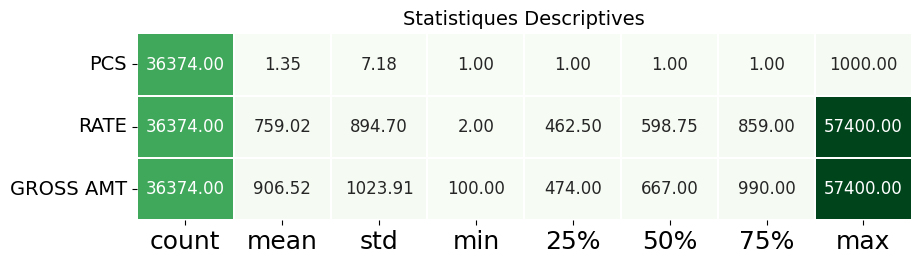

In [24]:
def desc_stats(dataframe):
    desc_df = pd.DataFrame(index=dataframe.columns,
                           columns=dataframe.describe().T.columns,
                           data=dataframe.describe().T)

    f, ax = plt.subplots(figsize=(10,
                                  desc_df.shape[0] * 0.81))
    sns.heatmap(desc_df,
                annot=True,
                cmap="Greens",
                fmt='.2f',
                ax=ax,
                linecolor='white',
                linewidths=1.1,
                cbar=False,
                annot_kws={"size": 12}
            )
    plt.xticks(size=18)
    plt.yticks(size=14,
               rotation=0)
    plt.title("Statistiques Descriptives", size=14)
    plt.show()


desc_stats(pandasDF.select_dtypes(include=[float, int]))

# Market basket analysis


In [42]:
# Etape 1: Enlever les donnees non utiles
csData = finalDf.filter(finalDf.SKU != 'empty' ).filter(finalDf.SKU != 'SHIPPING')

In [43]:
csData.select(csData.SKU).distinct().count()

4596

In [25]:
# Etape 2: Praparer les donnees pour l'algorithme 
groupedData = csData.groupBy("CUSTOMER").agg(F.collect_set("SKU").alias("Products"))
groupedData.show()

+--------------------+--------------------+
|            CUSTOMER|            Products|
+--------------------+--------------------+
|        FARIA ESSOPP|[J0116-TP-XL, JNE...|
|        BINCY SKARIA|[SET242-KR-PP-XXX...|
|        ANJU BHARATI|[JNE3668-TP-XS, J...|
| VINODHA PUSPANATHAN|[MEN5031-KR-S, ME...|
|DHENOOGA RAVINTHERAN|[BTM021-XL, JNE37...|
|           MONIYSHAA|[J0212-DR-S, J023...|
|       MAAVI FASHION|[SET300-KR-NP-S, ...|
|      NAYANA SAWLANI|[JNE3560-KR-M, J0...|
|          RIVAAN LLC|[JNE3030-KR-M, JN...|
|     THANA MARIMUTHU|[CMB5-JNE3853, SE...|
|          ENTHULEGA |[SET329-KR-NP-XL,...|
|      YASHWINI REDDY|[SET230-KR-PP-XXL...|
|   GEETHA RAJA GOPAL|[BL085-L, BL085-M...|
|PUNITHAVATHY KARU...|[SET328-KR-NP-XL,...|
|      KHANJANA MOJEE|[SET267-KR-NP-XXL...|
|                REGA|[JNE2032-KR-205-L...|
|   COTTON CLOSET LTD|[JNE3405-KR-L, JN...|
|       AKASH KAUSHAL|[MEN5023-KR-XL, J...|
|     MR ALWAR MURALI|[BTM008-XXL, SET2...|
|       MANGALAM SHOP|[J0109-SKD

In [37]:
# Etape 3: appliquer l'agorithme Apriori (FPGrowth) pour avoir les regles d'association
fp_growth = FPGrowth(itemsCol="Products", minSupport=0.05, minConfidence=0.5)
trainingData = groupedData.sample(fraction=0.7, seed=42) 
model = fp_growth.fit(trainingData)

In [57]:
# Afficher les elements frequents.
frequentItems = model.freqItemsets
display(frequentItems.toPandas().sort_values(by='freq').head(5))

# Afficher les regles d'association generer .
associationRules = model.associationRules
print("nombre de regles: ",associationRules.count())
associationRules.toPandas().head(10)

,items,freq
0,[JNE3627-KR-XXL],5
251,"[JNE3557-KR-L, JNE3557-KR-M, JNE3555-KR-XL, JN...",5
250,"[JNE3557-KR-L, JNE3557-KR-M, JNE3555-KR-XL]",5
249,"[JNE3557-KR-L, JNE3557-KR-M]",5
248,"[JNE3557-KR-L, JNE3555-KR-XL, JNE3555-KR-L]",5


nombre de regles:  664


,antecedent,consequent,confidence,lift,support
0,"[SET268-KR-NP-XXXL, SET268-KR-NP-XXL, SET268-K...",[SET268-KR-NP-L],1.000000,16.800000,0.059524
1,"[SET268-KR-NP-XXXL, SET268-KR-NP-XXL, SET268-K...",[SET268-KR-NP-M],1.000000,10.500000,0.059524
2,"[SET268-KR-NP-L, SET268-KR-NP-XXL, SET268-KR-N...",[SET268-KR-NP-M],1.000000,10.500000,0.059524
3,"[SET268-KR-NP-L, SET268-KR-NP-XXL, SET268-KR-N...",[SET268-KR-NP-XXXL],1.000000,16.800000,0.059524
4,"[SET268-KR-NP-XXXL, SET268-KR-NP-L, SET268-KR-...",[SET268-KR-NP-M],1.000000,10.500000,0.059524
5,"[SET268-KR-NP-XXXL, SET268-KR-NP-L, SET268-KR-...",[SET268-KR-NP-S],1.000000,14.000000,0.059524
6,"[SET268-KR-NP-XXXL, SET268-KR-NP-L, SET268-KR-...",[SET268-KR-NP-XXL],1.000000,16.800000,0.059524
7,"[JNE3576-KR-L, JNE3576-KR-M, JNE3576-KR-XL]",[JNE3576-KR-XXL],0.833333,8.750000,0.059524
8,[JNE3567-KR-L],[JNE3567-KR-XL],0.833333,14.000000,0.059524
9,[JNE3567-KR-L],[JNE3567-KR-XXL],0.833333,11.666667,0.059524


# Cross-Selling analysis

In [48]:
# Apres avoir entrainer le modele on peut l'utiliser pour genrer des prediction 
# (Recommendation sur le prochain item)
testingData = groupedData.subtract(trainingData)
crossSelling = model.transform(testingData)
crossSelling.toPandas().head(10)

,CUSTOMER,Products,prediction
0,ANJU BHARATI,"[JNE3668-TP-XS, J0118-TP-L, MEN5016-KR-XXL, JN...","[SET268-KR-NP-XXL, SET268-KR-NP-XXXL]"
1,MAAVI FASHION,"[SET300-KR-NP-S, SET323-KR-NP-L, JNE3687-TU-L,...","[JNE3555-KR-XXL, JNE3555-KR-XL, JNE3555-KR-XXX..."
2,RIVAAN LLC,"[JNE3030-KR-M, JNE3679-TU-XXL, JNE2132-KR-398-...","[JNE3405-KR-M, JNE3557-KR-L, JNE3557-KR-M, SET..."
3,THANA MARIMUTHU,"[CMB5-JNE3853, SET345-KR-NP-XS, JNE3405-KR-L, ...","[JNE3405-KR-XL, SET268-KR-NP-XXL, SET268-KR-NP..."
4,PUNITHAVATHY KARUPIAH,"[SET328-KR-NP-XL, SET295-KR-NP-XXL, JNE3548-KR...","[JNE3548-KR-XXL, JNE3556-KR-XL, JNE3555-KR-L, ..."
5,KHANJANA MOJEE,"[SET267-KR-NP-XXL, J0352-KR-M, SET318-KR-SHA-S...",[]
6,REGA,"[JNE2032-KR-205-L, JNE3714-KR-XL, JNE3386-KR-S...","[JNE2014-KR-178-M, JNE2014-KR-178-XL, JNE3555-..."
7,MANGALAM SHOP,"[J0109-SKD-M, J0285-SKD-L, J0109-SKD-XS, J0109...",[]
8,KHIRTHIKA,"[JNE3447-KR-M, JNE3445-KR-XL, JNE3447-KR-S, JN...",[]
9,FUSION FASHIONS CORP.,"[SET145-KR-NP-M, JNE2049-KR-351-XXXL, J0118-TP...","[SET268-KR-NP-M, SET268-KR-NP-XL, SET268-KR-NP..."


In [41]:
crossSelling.toPandas()\
.to_csv("cross-selling_.csv",header=True,index=False, sep="|")

# RFM Analysis


In [ ]:
print(pandasDF['DATE'].max())

In [ ]:
import datetime as dt
#on prend le date la plus recente possible
today_date = dt.datetime(2022, 5, 15)

rfm = pandasDF.groupby('CUSTOMER').agg({
    'DATE': lambda x: (today_date - x.max()).days,
    'index': lambda x: x.nunique(),
    'GROSS AMT': lambda x: x.sum()
})

rfm.columns = ['recency', 'frequency', 'monetary']
# filter the 'monetary' column using boolean condition
rfm = rfm[rfm['monetary'] > 0]
rfm = rfm.reset_index()

rfm.head()

In [ ]:
def get_rfm_scores(dataframe) -> pd.core.frame.DataFrame:

    df_ = dataframe.copy()
    df_["recency_score"] = pd.qcut(df_["recency"], 5, labels=[5, 4, 3, 2, 1])
    df_["frequency_score"] = pd.qcut(
        df_["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
    )
    df_["monetary_score"] = pd.qcut(df_["monetary"], 5, labels=[1, 2, 3, 4, 5])
    df_["RFM_SCORE"] = df_["recency_score"].astype(str) + df_["frequency_score"].astype(str)

    return df_


rfm = get_rfm_scores(rfm)

In [ ]:
seg_map = {r'[1-2][1-2]': 'en hibernation',
           r'[1-2][3-4]': 'en risque',
           r'[1-2]5': 'ne peut pas perdre',
           r'3[1-2]': 'prsq dormant',
           r'33': 'besoin d\'attention',
           r'[3-4][4-5]': 'clients fidèles',
           r'41': 'prometteur',
           r'51': 'nouveaux clients',
           r'[4-5][2-3]': 'loyal_potentiels',
           r'5[4-5]': 'champions'}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

rfm.head()

In [ ]:
segments = rfm["segment"].value_counts().sort_values(ascending=False)
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 10)
squarify.plot(
    sizes=segments,
    label=[label for label in seg_map.values()],
    color=[
        "#AFB6B5",
        "#F0819A",
        "#926717",
        "#F0F081",
        "#81D5F0",
        "#C78BE5",
        "#748E80",
        "#FAAF3A",
        "#7B8FE4",
        "#86E8C0",
    ],
    pad=False,
    bar_kwargs={"alpha": 1},
    text_kwargs={"fontsize": 15},
)
plt.title("Carte de segmentation client", fontsize=20)
plt.xlabel("Fréquence", fontsize=18)
plt.ylabel("Récence", fontsize=18)
plt.show()

In [ ]:
from IPython.display import display, HTML
X = rfm[['recency_score', 'frequency_score']]
labels = rfm['segment']
results = {
    'Number of Observations': [X.shape[0]],
    'Number of Segments': [labels.nunique()],
    'Calinski Harabasz Score': [round(calinski_harabasz_score(X, labels), 3)],
    'Davies Bouldin Score': [round(davies_bouldin_score(X, labels), 3)]
}
df_results = pd.DataFrame(results,index=["valeur"])
df_results.T

In [ ]:
# sélectionne uniquement les colonnes 'récence', 'monétaire', 'fréquence' et 'segment' du RFM DataFrame.
# regroupe le DataFrame par la colonne 'segment'.
# applique les fonctions d'agrégation 'mean', 'std', 'max' et 'min' à chaque colonne pour chaque groupe de segments.
rfm[['recency', 'monetary', 'frequency', 'segment']]\
.groupby('segment')\
.agg({'mean','std','max','min'})

In [ ]:
palette = 'Set2'
plt.figure(figsize=(18, 8))
ax = sns.countplot(data=rfm,
                   x='segment',
                   palette=palette)
total = len(rfm.segment)
for patch in ax.patches:
    percentage = '{:.1f}%'.format(100 * patch.get_height()/total)
    x = patch.get_x() + patch.get_width() / 2 - 0.17
    y = patch.get_y() + patch.get_height() * 1.005
    ax.annotate(percentage, (x, y), size=14)
plt.title('Nombre de Clients par Segments', size=16)
plt.xlabel('Segment', size=14)
plt.ylabel('Compte', size=14)
plt.xticks(size=10)
plt.yticks(size=10)
plt.show()

In [ ]:
plt.figure(figsize=(18, 8))
sns.scatterplot(
    data=rfm, x="recency", y="frequency", hue="segment", palette=palette, s=60
)
plt.title("Recence & Frequence par Segments", size=16)
plt.xlabel("Recency", size=12)
plt.ylabel("Frequency", size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.legend(loc="best", fontsize=12, title="Segments", title_fontsize=14)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("RFM Segment Analysis", size=14)
feature_list = ["recency", "monetary", "frequency"]
for idx, col in enumerate(feature_list):
    sns.boxplot(
        ax=axes[idx], data=rfm, x="segment", y=feature_list[idx], palette=palette
    )
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=60)
    if idx == 1:
        axes[idx].set_ylim([0, 400])
    if idx == 2:
        axes[idx].set_ylim([0, 30])
plt.tight_layout()
plt.show()

# CLV

In [ ]:
cltv_df = pandasDF.groupby("CUSTOMER").agg(
    {
        "DATE": [
            lambda x: (x.max() - x.min()).days,
            lambda x: (today_date - x.min()).days,
        ],
        "index": "nunique",
        "GROSS AMT": "sum",
    }
)

cltv_df.columns = cltv_df.columns.droplevel(0)
cltv_df.columns = ["recency", "T", "frequency", "monetary"]
cltv_df.head()

# Cohort Analysis

In [ ]:
from operator import attrgetter
import matplotlib.colors as mcolors

def CohortAnalysis(dataframe):

    data = dataframe.copy()
    data = data[["CUSTOMER", "index", "DATE"]].drop_duplicates()
    #converting to date like as it doesnt recognize the mm-dd-yy
    data["DATE"] = pd.to_datetime(data["DATE"],infer_datetime_format=True) 
    data["order_month"] = data["DATE"].dt.to_period("M")
    data["cohort"] = (
        data.groupby("CUSTOMER")["DATE"].transform(
            "min").dt.to_period("M")
    )
    cohort_data = (
        data.groupby(["cohort", "order_month"])
        .agg(n_customers=("CUSTOMER", "nunique"))
        .reset_index(drop=False)
    )
    cohort_data["period_number"] = (cohort_data.order_month - cohort_data.cohort).apply(
        attrgetter("n")
    )
    cohort_pivot = cohort_data.pivot_table(
        index="cohort", columns="period_number", values="n_customers"
    )
    cohort_size = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    with sns.axes_style("white"):
        fig, ax = plt.subplots(
            1, 2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]}
        )
        sns.heatmap(
            retention_matrix,
            mask=retention_matrix.isnull(),
            annot=True,
            cbar=False,
            fmt=".0%",
            cmap="coolwarm",
            ax=ax[1],
        )
        ax[1].set_title("Monthly Cohorts: User Retention", fontsize=14)
        ax[1].set(xlabel="# of periods", ylabel="")
        white_cmap = mcolors.ListedColormap(["white"])
        sns.heatmap(
            pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"}),
            annot=True,
            cbar=False,
            fmt="g",
            cmap=white_cmap,
            ax=ax[0],
        )
        fig.tight_layout()

In [ ]:
pandasDF = finalDf.toPandas()
CohortAnalysis(pandasDF)